In [53]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from methods import ETL
from prophet import Prophet
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [54]:
df_netgen = pd.read_csv(r'C:\Users\TobyWong\Desktop\UNCC\5122\EIA_end_customer_sales_power_prediction_NC\data\nc_net_generation_all.csv')
df_netgen.head()

,period,location,stateDescription,sectorid,sectorDescription,fueltypeid,fuelTypeDescription,generation,generation-units
0,2001-01,NC,North Carolina,96,All Commercial,ALL,all fuels,13.646,thousand megawatthours
1,2001-01,NC,North Carolina,97,All Industrial,ALL,all fuels,303.266,thousand megawatthours
2,2001-02,NC,North Carolina,96,All Commercial,ALL,all fuels,11.036,thousand megawatthours
3,2001-02,NC,North Carolina,97,All Industrial,ALL,all fuels,269.517,thousand megawatthours
4,2001-03,NC,North Carolina,96,All Commercial,ALL,all fuels,7.545,thousand megawatthours


In [55]:
df_netgen = pd.read_csv(r'C:\Users\TobyWong\Desktop\UNCC\5122\EIA_end_customer_sales_power_prediction_NC\data\nc_net_generation_all.csv')
df_netgen.head()
df_netgen = df_netgen.drop(columns = ['fuelTypeDescription', 'fueltypeid', 'sectorid', 'generation-units'])
df_netgen = df_netgen.rename(columns={"location": "stateid"})
df_netgen["sector_type"] = df_netgen["sectorDescription"].map({
    "All Commercial": "COM",
    "All Industrial": "IND"
})

df_netgen = df_netgen.drop(columns=["sectorDescription"])
df_netgen["period"] = pd.to_datetime(df_netgen["period"] + "-01")
df_netgen = df_netgen.drop(columns = ['stateDescription'])
df_netgen = df_netgen.rename(columns={"generation": "actual_value"})
df_netgen["salesUnit"] = "million kilowatt hours"


In [56]:
df_netgen.head()

,period,stateid,actual_value,sector_type,salesUnit
0,2001-01-01,NC,13.646,COM,million kilowatt hours
1,2001-01-01,NC,303.266,IND,million kilowatt hours
2,2001-02-01,NC,11.036,COM,million kilowatt hours
3,2001-02-01,NC,269.517,IND,million kilowatt hours
4,2001-03-01,NC,7.545,COM,million kilowatt hours


In [57]:
df_netgen["period"] = pd.to_datetime(df_netgen["period"])
df_netgen = df_netgen[~df_netgen["period"].isin(pd.to_datetime(["2025-12-01", "2026-01-01"]))]

In [58]:
df_netgen.count()

period          598
stateid         598
actual_value    598
sector_type     598
salesUnit       598
dtype: int64

In [59]:
def calculate_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    r2 = r2_score(y_true, y_pred)

    mask = y_true != 0
    if mask.sum() == 0:
        mape = np.nan
    else:
        mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100

    return r2, mape


def run_prophet(train_df, test_df, full_df, periods=24):
    prophet_train = train_df.rename(columns={"period": "ds", "actual_value": "y"})[["ds", "y"]]
    prophet_test = test_df.rename(columns={"period": "ds", "actual_value": "y"})[["ds", "y"]]
    prophet_full = full_df.rename(columns={"period": "ds", "actual_value": "y"})[["ds", "y"]]

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive"
    )
    model.fit(prophet_train)

    test_forecast = model.predict(prophet_test[["ds"]])
    test_pred = test_forecast["yhat"].values

    r2, mape = calculate_metrics(prophet_test["y"].values, test_pred)

    final_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="multiplicative",
        changepoint_prior_scale=0.1,
        seasonality_prior_scale=10.0
    )
    final_model.fit(prophet_full)

    future = final_model.make_future_dataframe(periods=periods, freq="MS")
    forecast = final_model.predict(future)

    future_forecast = forecast[forecast["ds"] > prophet_full["ds"].max()][["ds", "yhat"]].copy()
    future_forecast.columns = ["period", "predicted_value"]

    test_out = test_df.copy()
    test_out["predicted_value"] = test_pred

    return {
        "model_name": "Prophet",
        "r2": r2,
        "mape": mape,
        "test_predictions": test_out,
        "future_forecast": future_forecast
    }


def run_sarima(train_df, test_df, full_df, periods=24):
    train_series = train_df.set_index("period")["actual_value"].asfreq("MS")
    test_series = test_df.set_index("period")["actual_value"].asfreq("MS")
    full_series = full_df.set_index("period")["actual_value"].asfreq("MS")

    model = SARIMAX(
        train_series,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fit = model.fit(disp=False)

    test_pred = fit.forecast(steps=len(test_series))

    r2, mape = calculate_metrics(test_series.values, test_pred.values)

    final_model = SARIMAX(
        full_series,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    final_fit = final_model.fit(disp=False)

    future_pred = final_fit.forecast(steps=periods)
    future_forecast = future_pred.reset_index()
    future_forecast.columns = ["period", "predicted_value"]

    test_out = test_df.copy()
    test_out["predicted_value"] = test_pred.values

    return {
        "model_name": "SARIMA",
        "r2": r2,
        "mape": mape,
        "test_predictions": test_out,
        "future_forecast": future_forecast
    }


def choose_best_model(prophet_result, sarima_result):    
    if prophet_result["mape"] < sarima_result["mape"]:
        return prophet_result
    elif sarima_result["mape"] < prophet_result["mape"]:
        return sarima_result
    else:
        return prophet_result if prophet_result["r2"] >= sarima_result["r2"] else sarima_result



In [60]:
all_results = []
metrics_summary = []
forecast_horizon = 24
stateid = 'NC'

for sector in ["COM", "IND"]:
    sector_df = df_netgen[df_netgen["sector_type"] == sector].copy()
    sector_df = sector_df.sort_values("period").reset_index(drop=True)

    split_idx = int(len(sector_df) * 0.7)
    train_df = sector_df.iloc[:split_idx].copy()
    test_df = sector_df.iloc[split_idx:].copy()

    prophet_result = run_prophet(train_df, test_df, sector_df, periods=forecast_horizon)
    sarima_result = run_sarima(train_df, test_df, sector_df, periods=forecast_horizon)

    best_result = choose_best_model(prophet_result, sarima_result)

    metrics_summary.append({
        "sector_type": sector,
        "prophet_r2": prophet_result["r2"],
        "prophet_mape": prophet_result["mape"],
        "sarima_r2": sarima_result["r2"],
        "sarima_mape": sarima_result["mape"],
        "selected_model": best_result["model_name"]
    })

    # actuals
    actual_out = sector_df.copy()
    actual_out["predicted_value"] = np.nan
    actual_out["data_label"] = "Actual"
    actual_out["model_used"] = best_result["model_name"]

    # test set predictions
    test_out = best_result["test_predictions"].copy()
    test_out["data_label"] = "Predicted"
    test_out["model_used"] = best_result["model_name"]

    # forecasts
    forecast_out = best_result["future_forecast"].copy()
    forecast_out["actual_value"] = np.nan
    forecast_out["sector_type"] = sector
    forecast_out["stateid"] = stateid
    forecast_out["salesUnit"] = sector_df["salesUnit"].iloc[0] if "salesUnit" in sector_df.columns else np.nan
    forecast_out["data_label"] = "Forecast"
    forecast_out["model_used"] = best_result["model_name"]

    final_cols = [
        "period", 
        "stateid", 
        "salesUnit", 
        "sector_type",
        "actual_value", 
        "predicted_value", 
        "data_label", 
        "model_used"
    ]

    for temp_df in [actual_out, test_out, forecast_out]:
        for col in final_cols:
            if col not in temp_df.columns:
                temp_df[col] = np.nan

    sector_final = pd.concat(
        [actual_out[final_cols], test_out[final_cols], forecast_out[final_cols]],
        ignore_index=True
    )
    all_results.append(sector_final)

20:04:59 - cmdstanpy - INFO - Chain [1] start processing
20:04:59 - cmdstanpy - INFO - Chain [1] done processing
20:04:59 - cmdstanpy - INFO - Chain [1] start processing
20:04:59 - cmdstanpy - INFO - Chain [1] done processing
20:05:00 - cmdstanpy - INFO - Chain [1] start processing
20:05:00 - cmdstanpy - INFO - Chain [1] done processing
20:05:01 - cmdstanpy - INFO - Chain [1] start processing
20:05:01 - cmdstanpy - INFO - Chain [1] done processing


In [61]:
final_forecast_df = pd.concat(all_results, ignore_index=True)
final_forecast_df = final_forecast_df.sort_values(
    ["sector_type", "period", "data_label"]
).reset_index(drop=True)

metrics_df = pd.DataFrame(metrics_summary)

print("\nModel comparison:")
print(metrics_df)

print("\nFinal forecast dataframe:")
final_forecast_df.head(20)


Model comparison:
  sector_type  prophet_r2  prophet_mape  sarima_r2  sarima_mape selected_model
0         COM  -22.828229     72.361914  -6.581681    39.429846         SARIMA
1         IND    0.213035      9.817402  -0.350425    14.429365        Prophet

Final forecast dataframe:


,period,stateid,salesUnit,sector_type,actual_value,predicted_value,data_label,model_used
0,2001-01-01,NC,million kilowatt hours,COM,13.646,NaN,Actual,SARIMA
1,2001-02-01,NC,million kilowatt hours,COM,11.036,NaN,Actual,SARIMA
2,2001-03-01,NC,million kilowatt hours,COM,7.545,NaN,Actual,SARIMA
3,2001-04-01,NC,million kilowatt hours,COM,2.667,NaN,Actual,SARIMA
4,2001-05-01,NC,million kilowatt hours,COM,5.345,NaN,Actual,SARIMA
5,2001-06-01,NC,million kilowatt hours,COM,6.517,NaN,Actual,SARIMA
6,2001-07-01,NC,million kilowatt hours,COM,7.431,NaN,Actual,SARIMA
7,2001-08-01,NC,million kilowatt hours,COM,10.588,NaN,Actual,SARIMA
8,2001-09-01,NC,million kilowatt hours,COM,4.599,NaN,Actual,SARIMA
9,2001-10-01,NC,million kilowatt hours,COM,5.942,NaN,Actual,SARIMA


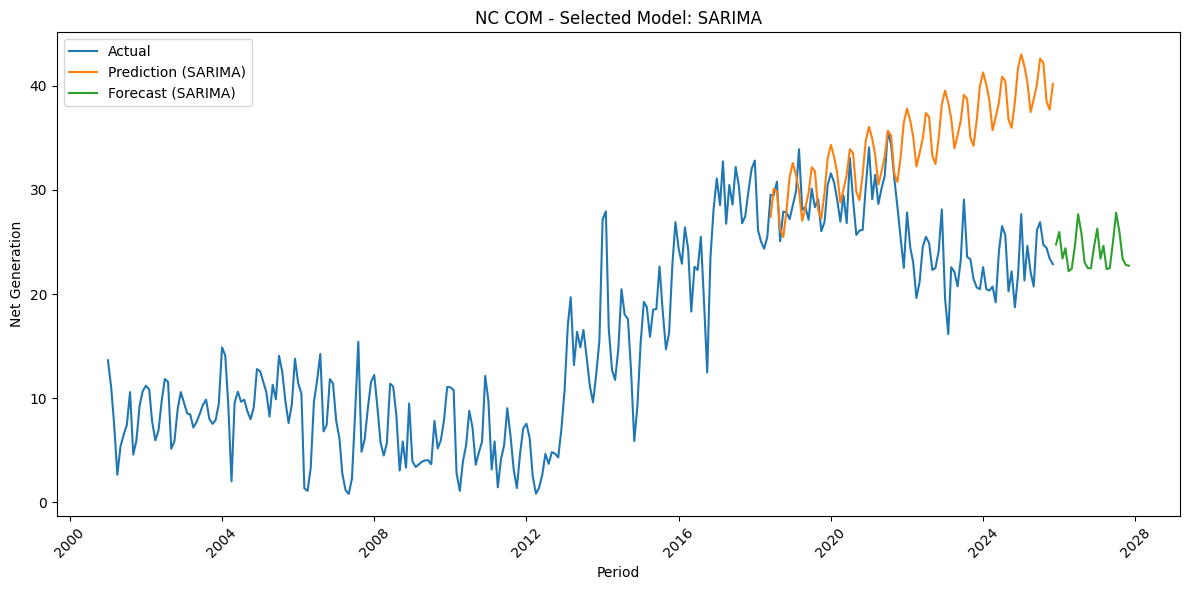

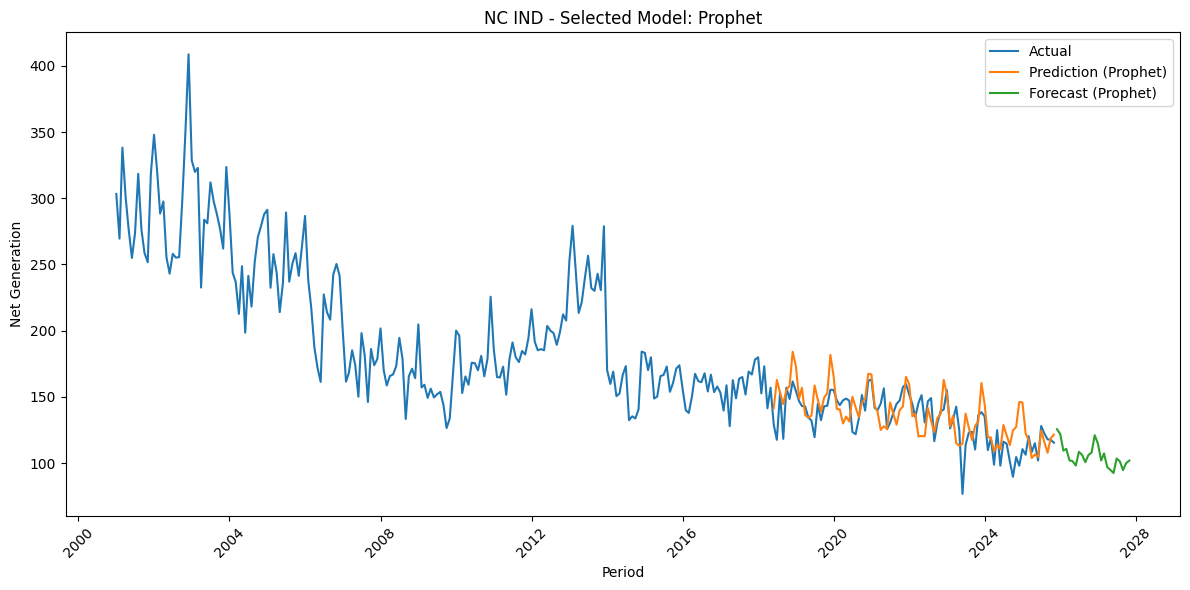

In [62]:
for sector in ["COM", "IND"]:
    plot_df = final_forecast_df[final_forecast_df["sector_type"] == sector].copy()
    selected_model = plot_df["model_used"].dropna().iloc[0]

    actual_df = plot_df[plot_df["data_label"] == "Actual"]
    test_df = plot_df[plot_df["data_label"] == "Predicted"]
    forecast_df = plot_df[plot_df["data_label"] == "Forecast"]

    plt.figure(figsize=(12, 6))
    plt.plot(actual_df["period"], actual_df["actual_value"], label="Actual")
    plt.plot(test_df["period"], test_df["predicted_value"], label=f"Prediction ({selected_model})")
    plt.plot(forecast_df["period"], forecast_df["predicted_value"], label=f"Forecast ({selected_model})")
    plt.xlabel("Period")
    plt.ylabel("Net Generation")
    plt.title(f"{stateid} {sector} - Selected Model: {selected_model}")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [67]:
final_forecast_df = final_forecast_df[final_forecast_df["data_label"] != "Predicted"]
final_forecast_df.count()
df_netgen = final_forecast_df.copy()
df_netgen["data_source"] = 'net_generation'
df_netgen.head(10)

,period,stateid,salesUnit,sector_type,actual_value,predicted_value,data_label,model_used,data_source
0,2001-01-01,NC,million kilowatt hours,COM,13.646,NaN,Actual,SARIMA,net_generation
1,2001-02-01,NC,million kilowatt hours,COM,11.036,NaN,Actual,SARIMA,net_generation
2,2001-03-01,NC,million kilowatt hours,COM,7.545,NaN,Actual,SARIMA,net_generation
3,2001-04-01,NC,million kilowatt hours,COM,2.667,NaN,Actual,SARIMA,net_generation
4,2001-05-01,NC,million kilowatt hours,COM,5.345,NaN,Actual,SARIMA,net_generation
5,2001-06-01,NC,million kilowatt hours,COM,6.517,NaN,Actual,SARIMA,net_generation
6,2001-07-01,NC,million kilowatt hours,COM,7.431,NaN,Actual,SARIMA,net_generation
7,2001-08-01,NC,million kilowatt hours,COM,10.588,NaN,Actual,SARIMA,net_generation
8,2001-09-01,NC,million kilowatt hours,COM,4.599,NaN,Actual,SARIMA,net_generation
9,2001-10-01,NC,million kilowatt hours,COM,5.942,NaN,Actual,SARIMA,net_generation


In [66]:
df_netgen.count()

period             646
stateid            646
salesUnit          646
sector_type        646
actual_value       598
predicted_value     48
data_label         646
model_used         646
data_source        646
dtype: int64